##Problem Statement
The Online E-commerce company want to Predict whether a customer will return to shop in the next 3 months based on their past behavior and engagement to focus on the marketing of that customer

target variable:
Will_return = 1
Not_return = 0

##Import Libraries

In [623]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


##Load data

In [624]:
df = pd.read_csv("/content/customer_return_prediction.csv")

##Basic analysis

In [625]:
df.head()


,CustomerID,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek,WillReturn
0,1,49,Female,1,4319.21,536.0,7.0,7,73,23,28,1
1,2,29,Female,44,2235.14,545.0,5.0,1,25,5,21,1
2,3,35,Male,40,789.00,232.0,8.0,9,28,45,2,1
3,4,24,Male,32,6868.02,183.0,29.0,8,44,6,10,1
4,5,41,Male,23,6713.88,484.0,10.0,0,67,27,12,1


In [626]:
df.shape

(5000, 12)

In [627]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5000 non-null   int64  
 1   Age                          5000 non-null   int64  
 2   Gender                       5000 non-null   object 
 3   TotalPurchasesLast6Months    5000 non-null   int64  
 4   AvgOrderValue                4850 non-null   float64
 5   BrowsingTime                 4850 non-null   float64
 6   DiscountUsage                4850 non-null   float64
 7   CustomerSupportInteractions  5000 non-null   int64  
 8   DaysSinceLastPurchase        5000 non-null   int64  
 9   EmailClicksLastMonth         5000 non-null   int64  
 10  AppSessionsLastWeek          5000 non-null   int64  
 11  WillReturn                   5000 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 468.9+ KB


In [628]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5000.0,2500.500000,1443.520003,1.00,1250.7500,2500.500,3750.2500,5000.00
Age,5000.0,40.944200,13.609149,18.00,29.0000,41.000,53.0000,64.00
TotalPurchasesLast6Months,5000.0,30.223800,20.085756,0.00,14.0000,29.000,45.0000,177.00
AvgOrderValue,4850.0,3547.055381,2128.437039,55.44,1703.1925,3522.015,5238.2725,13998.22
BrowsingTime,4850.0,302.285979,171.459801,5.00,151.0000,300.000,453.0000,599.00
DiscountUsage,4850.0,14.435258,8.676612,0.00,7.0000,14.000,22.0000,29.00
CustomerSupportInteractions,5000.0,4.564600,2.871912,0.00,2.0000,5.000,7.0000,9.00
DaysSinceLastPurchase,5000.0,44.364000,26.009560,0.00,22.0000,44.000,67.0000,89.00
EmailClicksLastMonth,5000.0,24.566400,14.479721,0.00,12.0000,25.000,37.0000,49.00
AppSessionsLastWeek,5000.0,14.338200,8.614236,0.00,7.0000,14.000,22.0000,29.00


In the dataset their are the 5000 rows of the data and the 12 no. of columns and the 'custormer Id' is the unique column in dataset

In [629]:
df['WillReturn'].value_counts()

,count
WillReturn,
1,4242
0,758


Also check the no. of counts of the target variables that are present in the dataset to understand the how dataset is imbalanced

##Remove unwanted columns like unique columns

In [630]:
df.drop(columns=["CustomerID"], inplace=True, axis=1)

In [631]:
df.shape

(5000, 11)

##Handle the Unknown Values

In [632]:
df.isin(['?','/','Unknown']).sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,0
BrowsingTime,0
DiscountUsage,0
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


#Handle the null values

In [633]:
df.isnull().sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,150
BrowsingTime,150
DiscountUsage,150
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


- There is found null values in dataset in the AvgOrderValue,BrowsingTime,DiscountUsage columns.
- we have to manage them, data present in columns are float type therefore we use mean() to Handle the null values

In [634]:
df.isnull().sum()
# Fill numerical columns with median
df['AvgOrderValue'].fillna(df['AvgOrderValue'].mean(), inplace=True)
df['BrowsingTime'].fillna(df['BrowsingTime'].mean(), inplace=True)
df['DiscountUsage'].fillna(df['DiscountUsage'].mean(), inplace=True)

In [635]:
df.isnull().sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,0
BrowsingTime,0
DiscountUsage,0
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


After the handling there is no any null values in dataset

##Handle the duplicate values

In [636]:
df.duplicated().sum()

np.int64(0)

There is no any duplicate values in the dataset

In [637]:
df.shape

(5000, 11)

##Divide the columns into the categorical and numerical columns

In [638]:
## split the data into the categorical and numerical data

categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [639]:
categorical_columns

Index(['Gender'], dtype='object')

In [640]:
numerical_columns

Index(['Age', 'TotalPurchasesLast6Months', 'AvgOrderValue', 'BrowsingTime',
       'DiscountUsage', 'CustomerSupportInteractions', 'DaysSinceLastPurchase',
       'EmailClicksLastMonth', 'AppSessionsLastWeek', 'WillReturn'],
      dtype='object')

##Convert the categorical_columns into the numerical data

In [641]:
## Map gender to 1 and 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [642]:
df

,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek,WillReturn
0,49,0,1,4319.21,536.0,7.0,7,73,23,28,1
1,29,0,44,2235.14,545.0,5.0,1,25,5,21,1
2,35,1,40,789.00,232.0,8.0,9,28,45,2,1
3,24,1,32,6868.02,183.0,29.0,8,44,6,10,1
4,41,1,23,6713.88,484.0,10.0,0,67,27,12,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,41,1,45,71.09,136.0,18.0,5,62,40,18,1
4996,18,0,5,2644.99,229.0,21.0,2,12,26,18,1
4997,28,0,1,3427.97,451.0,4.0,4,61,31,19,0
4998,56,0,10,1840.68,91.0,16.0,4,61,26,10,0


We convert the gender column into the numerical columns Male=1 and Female=0

##Find and remove the Outliers

In [643]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1


df=df[~((df < (Q1-1.5*IQR)) |(df> (Q3+1.5*IQR))).any(axis=1)]

In [644]:
df.shape

(4171, 11)

##Univariate Analysis

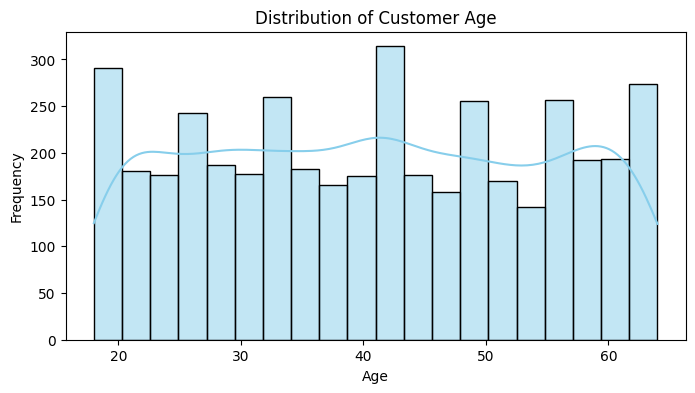

In [645]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Most customers are between 20-35 years old
A smaller portion of older customers (50-65) still shop online but less frequently.
Age may influence return probability, younger customers may be more engaged with the platform

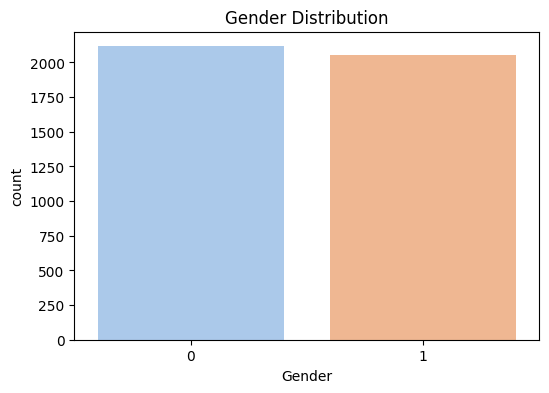

In [646]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.show()


 The dataset has roughly balanced Male and Female customers both are comparativly the same count of frequency

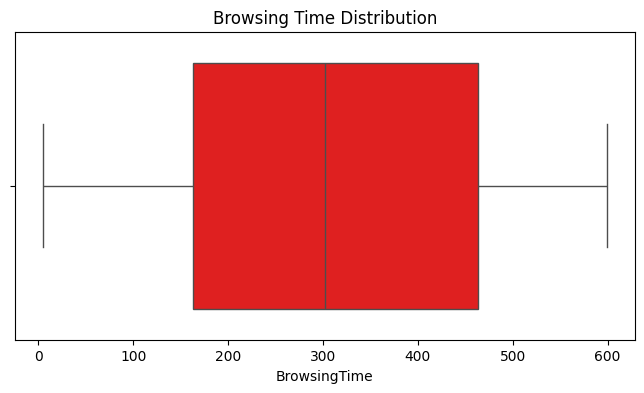

In [647]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['BrowsingTime'], color='red')
plt.title('Browsing Time Distribution')
plt.show()

Most customers spend under 300 minutes browsing per week Other are extremely high browsing times may indicate window shoppers

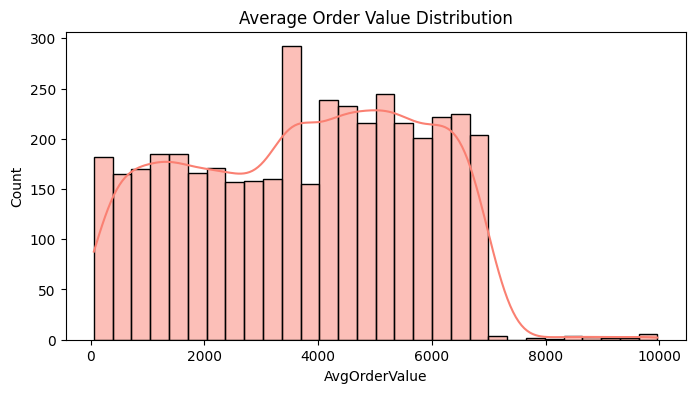

In [648]:
plt.figure(figsize=(8,4))
sns.histplot(df['AvgOrderValue'], bins=30, kde=True, color='salmon')
plt.title('Average Order Value Distribution')
plt.show()

Distribution is right-skewed Few customers have extremely high AvgOrderValue from the 4000 to the 7000 AvgOrderValue have the highest count of the frequency

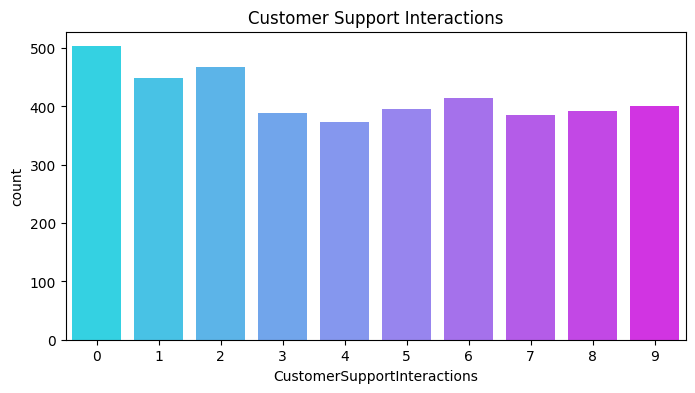

In [649]:
plt.figure(figsize=(8,4))
sns.countplot(x='CustomerSupportInteractions', data=df, palette='cool')
plt.title('Customer Support Interactions')
plt.show()

Highest Reaction from 0 to 2 Higher interaction counts may indicate dissatisfied customers

##Bivairate analysis

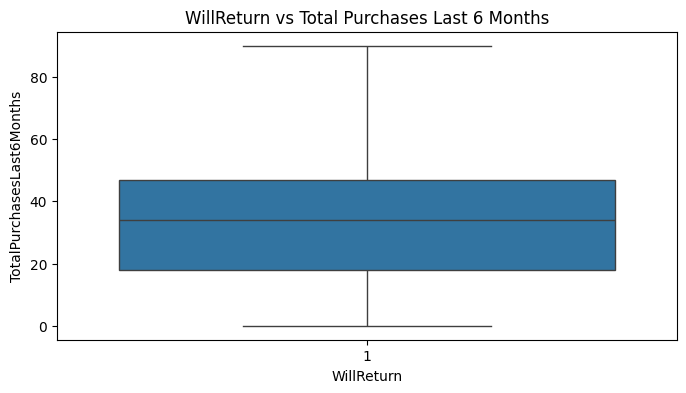

In [650]:
plt.figure(figsize=(8,4))
sns.boxplot(x='WillReturn', y='TotalPurchasesLast6Months', data=df)
plt.title('WillReturn vs Total Purchases Last 6 Months')
plt.show()



Returning customers generally have more purchases in the last 6 months

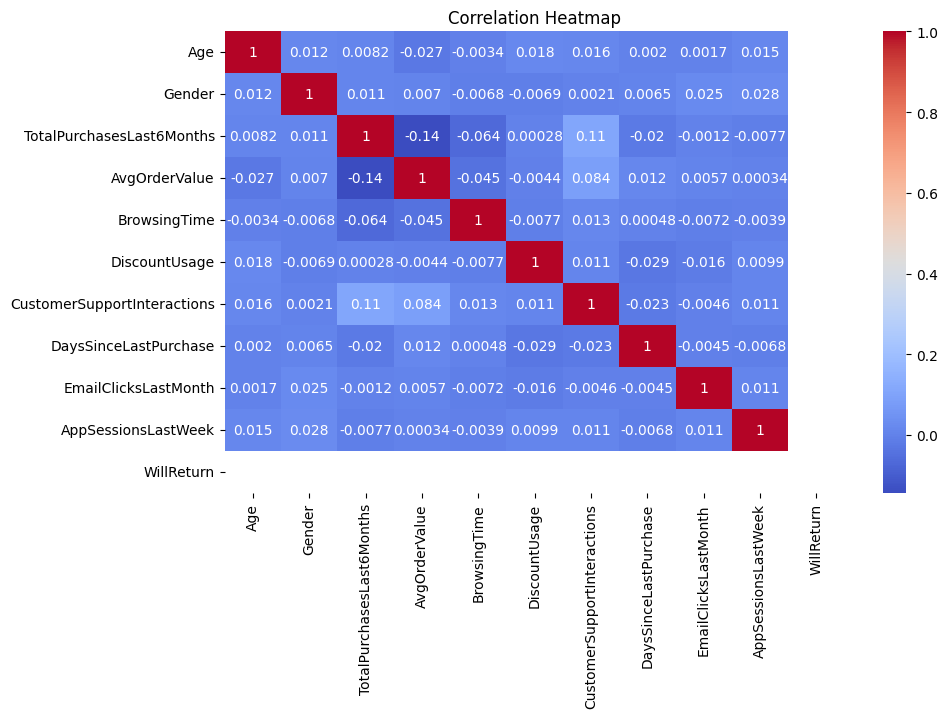

In [651]:
plt.figure(figsize=(10,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Features like TotalPurchasesLast6Months, AvgOrderValue, BrowsingTime, and DaysSinceLastPurchase are positively correlated with WillReturn

##Split the x and y variable

In [652]:
#split the dataset into x and y
# In the x it will include the everything except the target and the in the y only target variable
X=df.drop('WillReturn',axis=1)
y=df['WillReturn']

Here we split the dataset into the x and y variables and the in x include the all columns as input except the target column called willReturn

And the in y we include the only target varibale

##Train_Test_Split

In [653]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Here we split the dataset into the train and the test data it will be the train=80% and the test = 20%

##Feature Scaling

In [654]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In this step we Standartize the values such as the variance with the 0 and the standard deviation with 1 and -1 for the all values geting in the same scale

##ML Model Building

In [655]:
#Initializing the model
from sklearn.naive_bayes import GaussianNB as nb
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.tree import DecisionTreeClassifier as dt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score


In this step we import the models and the model metrics

In [656]:
nb_model = nb()
rf_model = rf()
dt_model = dt()

Initialize the model

In [657]:
## Training the model

nb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)



DecisionTreeClassifier()

Here we train all three models by the given X_train and the y_train values to the model

In [658]:
## Model evaluation

nb_pred = nb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

By the providing the X_test value we predict the values of y_pred by using the all models

In [659]:
## Confusion matrix print for all

print("Confusion matrix for Naive Bayes")
print(confusion_matrix(y_test, nb_pred))

Confusion matrix for Naive Bayes
[[835]]


In [660]:
print("Confusion matrix for Random Forest")
print(confusion_matrix(y_test, rf_pred))

Confusion matrix for Random Forest
[[835]]


In [661]:
print("Confusion matrix for Decision Tree")
print(confusion_matrix(y_test, dt_pred))

Confusion matrix for Decision Tree
[[835]]


- From the above all the steps the we find the confusion matrix
for the choose the best model
- But here all models gives the same output

In [662]:
nb_acc = recall_score(y_test, nb_pred)
rf_acc = recall_score(y_test, rf_pred)
dt_acc =recall_score(y_test, dt_pred)

In [663]:
print("recall for Naive Bayes: ", nb_acc)
print("recall for Random Forest: ", rf_acc)
print("recall for Decision Tree: ", dt_acc)

recall for Naive Bayes:  1.0
recall for Random Forest:  1.0
recall for Decision Tree:  1.0


Recall is chosen because in this problem, missing actual returning customers (false negatives) is more costly than incorrectly predicting a return. Therefore, maximizing recall ensures that most returning customers are correctly identified.

After the all the model building steps the model gives the perfect output as the model trained like overfiting that's why just we check the model is trained on the right manner or not.

Therefore,we apply the gridsearchCV for the checking the model

##GridSearchCV

Hypeparameter tunnig method to find optimal values of model

In [668]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier as rf


In [669]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

- n_estimators controls the number of trees in the forest
- max_depth controls how deep each tree can grow
- min_samples_split determines the minimum samples required to split a node

These parameters help balance between underfitting and overfitting.

In [680]:
grid_search = GridSearchCV(
    estimator=model, # Pass the instantiated classifier
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring='recall',

)

I used GridSearchCV with 5-fold cross-validation to find the best hyperparameters. Since the dataset is imbalanced, I used recall as the scoring metric to minimize false negatives

In [681]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='recall')

Here pass the values of the X_train and the y_train for the model

In [672]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:",grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 1.0


We use these lines to identify the best hyperparameters and see the expected performance of the model before training it fully or using it on test data.

In [673]:
y_pred = best_model.predict(X_test)

The pass the X_test for the prediction

In [674]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))


[[835]]


Here we also get the same output as the baseline model that we used before the gridsearchcv

In [675]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       835

    accuracy                           1.00       835
   macro avg       1.00      1.00      1.00       835
weighted avg       1.00      1.00      1.00       835



Also check the classification report of that include the all the metrics of the model that also gives the same output as the baseline model that's why the our model is perfect and the balanced between the overfitting and the underfitting

In [676]:


# New customer input data
new_data = pd.DataFrame({
    'Age': [28],
    'Gender': ['Male'],  # use 'Male' or 'Female'
    'TotalPurchasesLast6Months': [5],
    'AvgOrderValue': [250],
    'BrowsingTime': [120],
    'DiscountUsage': [2],
    'CustomerSupportInteractions': [1],
    'DaysSinceLastPurchase': [10],
    'EmailClicksLastMonth': [4],
    'AppSessionsLastWeek': [6]
})

new_data

,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek
0,28,Male,5,250,120,2,1,10,4,6


Here we pass the new data to the predict output from model

In [677]:
new_data['Gender'] = new_data['Gender'].map({'Male': 1, 'Female': 0})

# Scale the numerical features of the new data using the same StandardScaler
# Note: The original X includes 'Gender' as numerical after encoding. So, we scale all columns.
new_data = ss.transform(new_data)

prediction = best_model.predict(new_data)

first the convert the categorical gender column into the numerical column with map funciton and the standardize the model with the used variable ss to all values in the range of the variance of 0 and the standard deviation of -1 to 1
and the pass the that data to the predict model

In [678]:
prediction

array([1])

It predicts the 1 that makes sense the customer will return

In [679]:
## Interpret the prediction

if prediction[0] == 1:
    print("The model predicts the customer WILL return.")
else:
    print("The model predicts the customer WILL NOT return.")

The model predicts the customer WILL return.


By the given output of the model we interpret it for the user understanding

##Overall Analysis

- The dataset contains customer demographic, behavioral, and engagement features, which help in predicting whether a customer will return to shop
- From the analysis, purchase-related features such as TotalPurchasesLast6Months and AvgOrderValue play a major role in identifying returning customers
-  Customers who purchase frequently and spend more are more likely to return
- Customer engagement features like BrowsingTime, EmailClicksLastMonth, and AppSessionsLastWeek also show a strong influence
-  Higher engagement indicates higher chances of returning
- CustomerSupportInteractions shows an inverse relationship, where customers with many complaints or issues are less likely to return
